# Metrics for query workload 

We use this notebook to compute the metrics such as inference time, number of slices and average error for a specified query workload. 

We start by looking at the experiments for sampling interval $\delta$. The goal is to plot the tradeoff between sampling interval, error and computational time. This needs to compute the distances for each sampling interval. 

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import pickle
from scipy.spatial import distance
import yaml
import matplotlib.pyplot as plt

In [19]:
# Create a dataframe that holds the query details, error, time taken for inference and the number of slices
# for each query specified in the config_file
def compute_jsd(config_file):
    """Detailed analysis of the JSD for different queries."""
    with open(config_file, 'r', encoding='utf-8') as f:
        config = yaml.safe_load(f)

    jsd_analysis = pd.DataFrame(columns=[
        'exp_num', 'intv_type', 'intv_var', 'intv_time',
        'intv_val', 'query_var', 'query_time', 'inference_time', 
        'num_slices', 'jsd'
    ])

    for experiment in config:
        query_details = config[experiment]
        exp_num = int(experiment.split('_')[-1])

        # Get ground truth probability distribution
        # gt_results_folder = f"../{query_details['gt_results_folder']}/{query_details['expt_name']}"
        gt_results_folder = f'../{query_details["gt_results_folder"]}/parentq-all_inference-exact_queries'
        try: 
            with open(f"{gt_results_folder}/gt-exp-{exp_num}.pkl",
                    'rb') as f:
                gt, _ = pickle.load(f)
        except FileNotFoundError:
            print(
                f'Experiment {exp_num} has no ground truth file. Skipping...'
            )
            continue
        # print(f'Ground truth probability distribution: {gt}')

        dbn_results_folder = f"../{query_details['results_folder']}/{query_details['expt_name']}"
        dbn_output_filename = f"{dbn_results_folder}/posterior-exp-{exp_num}.pkl"
        # print(f'DBN output filename: {dbn_output_filename}')

        # If the posterior file does not exist, raise a warning and skip the experiment
        try:
            dbn_output = pd.read_pickle(dbn_output_filename)
            inferred_pd = dbn_output['Posterior']
            inference_time = dbn_output['InferenceTime']
            num_slices = dbn_output['TotalSlices']
        except FileNotFoundError:
            print(
                f'Experiment {exp_num} has no posterior file. Assuming zero probability...'
            )
            # Instead of skipping we can have 0 probabilities for all states
            inferred_pd = {state: 0 for state in gt.keys()}
            inference_time = None
            num_slices = None
        # print(f'Inferred probability distribution: {inferred_pd}')

        # Check if sum of gt.values() = 0
        if sum(gt.values()) == 0:
            print(
                f'Experiment {exp_num} has zero probability in ground truth!'
            )
        # Compute the Jensen-Shannon divergence
        jsd = distance.jensenshannon(list(inferred_pd.values()),
                                     list(gt.values()))

        # Populate the DataFrame
        jsd_analysis.loc[len(jsd_analysis)] = [
            exp_num,
            query_details['interventions'][0]['intervention_type'],
            query_details['interventions'][0]['intervention_variable'],
            query_details['interventions'][0]['intervention_start'],
            query_details['interventions'][0]['intervention_value'],
            query_details['query_variable'], query_details['query_time'],
            inference_time, num_slices, jsd
        ]

    return jsd_analysis

In [34]:
df_7 = compute_jsd('../configs/parentq-all_inference-exact_delta-7_queries.json')

Experiment 1 has no ground truth file. Skipping...
Experiment 2 has no ground truth file. Skipping...
Experiment 3 has no ground truth file. Skipping...
Experiment 4 has no ground truth file. Skipping...
Experiment 5 has no ground truth file. Skipping...
Experiment 6 has no ground truth file. Skipping...
Experiment 7 has no ground truth file. Skipping...
Experiment 8 has no ground truth file. Skipping...
Experiment 9 has no ground truth file. Skipping...
Experiment 10 has no ground truth file. Skipping...
Experiment 45 has no posterior file. Assuming zero probability...


/home/pboddavarama_umass_edu/.conda/envs/dbn-v2/lib/python3.10/site-packages/scipy/spatial/distance.py:1262: RuntimeWarning: invalid value encountered in divide
  p = p / np.sum(p, axis=axis, keepdims=True)


In [35]:
df_6 = compute_jsd('../configs/parentq-all_inference-exact_delta-6_queries.json')

Experiment 1 has no ground truth file. Skipping...
Experiment 2 has no ground truth file. Skipping...
Experiment 3 has no ground truth file. Skipping...
Experiment 4 has no ground truth file. Skipping...
Experiment 5 has no ground truth file. Skipping...
Experiment 6 has no ground truth file. Skipping...
Experiment 7 has no ground truth file. Skipping...
Experiment 8 has no ground truth file. Skipping...
Experiment 9 has no ground truth file. Skipping...
Experiment 10 has no ground truth file. Skipping...


In [36]:
df_5 = compute_jsd('../configs/parentq-all_inference-exact_delta-5_queries.json')

Experiment 1 has no ground truth file. Skipping...
Experiment 2 has no ground truth file. Skipping...
Experiment 3 has no ground truth file. Skipping...
Experiment 4 has no ground truth file. Skipping...
Experiment 5 has no ground truth file. Skipping...
Experiment 6 has no ground truth file. Skipping...
Experiment 7 has no ground truth file. Skipping...
Experiment 8 has no ground truth file. Skipping...
Experiment 9 has no ground truth file. Skipping...
Experiment 10 has no ground truth file. Skipping...


In [37]:
df_5

,exp_num,intv_type,intv_var,intv_time,intv_val,query_var,query_time,inference_time,num_slices,jsd
0,11,parameter_intervention,Muqb,1.0,0.80,Lqc,2.0,244.062285,20,0.043159
1,12,parameter_intervention,Muqa,1.0,1.00,Lqc,2.0,212.818257,20,0.070968
2,13,parameter_intervention,Lambdaqa,3.0,0.20,Lqb,4.0,415.360641,40,0.034562
3,14,parameter_intervention,Lambdaqa,1.0,0.60,Lqa,3.0,321.902150,30,0.074729
4,15,parameter_intervention,Muqb,1.0,0.80,Lqa,2.0,193.072787,20,0.104257
5,16,parameter_intervention,Muqa,2.0,1.00,Lqa,4.0,387.561857,40,0.074982
6,17,parameter_intervention,Rbc,2.0,0.70,Lqb,3.0,300.532876,30,0.095675
7,18,parameter_intervention,Muqa,1.0,1.00,Lqc,5.0,654.714929,50,0.084645
8,19,parameter_intervention,Rbc,1.0,0.70,Lqa,3.0,420.985240,30,0.111133
9,20,parameter_intervention,Muqa,2.0,1.00,Lqc,5.0,485.318798,50,0.068002


In [38]:
df_4 = compute_jsd('../configs/parentq-all_inference-exact_delta-4_queries.json')

Experiment 1 has no ground truth file. Skipping...
Experiment 2 has no ground truth file. Skipping...
Experiment 3 has no ground truth file. Skipping...
Experiment 4 has no ground truth file. Skipping...
Experiment 5 has no ground truth file. Skipping...
Experiment 6 has no ground truth file. Skipping...
Experiment 7 has no ground truth file. Skipping...
Experiment 8 has no ground truth file. Skipping...
Experiment 9 has no ground truth file. Skipping...
Experiment 10 has no ground truth file. Skipping...


In [39]:
df_4.head()

,exp_num,intv_type,intv_var,intv_time,intv_val,query_var,query_time,inference_time,num_slices,jsd
0,11,parameter_intervention,Muqb,1.0,0.8,Lqc,2.0,237.415105,40,0.043444
1,12,parameter_intervention,Muqa,1.0,1.0,Lqc,2.0,269.229069,40,0.069664
2,13,parameter_intervention,Lambdaqa,3.0,0.2,Lqb,4.0,479.808894,80,0.042283
3,14,parameter_intervention,Lambdaqa,1.0,0.6,Lqa,3.0,369.669080,60,0.069277
4,15,parameter_intervention,Muqb,1.0,0.8,Lqa,2.0,227.410040,40,0.103175


In [40]:
# Merge the 3 dataframes into one, for the column names inference_time, num_slices and jsd, append _7, _6 and _5 respectively
for col in ['inference_time', 'num_slices', 'jsd']:
    df_7.rename(columns={col: f'{col}_7'}, inplace=True)
    df_6.rename(columns={col: f'{col}_6'}, inplace=True)
    df_5.rename(columns={col: f'{col}_5'}, inplace=True)
    df_4.rename(columns={col: f'{col}_4'}, inplace=True)

In [41]:
# Merge the 3 dataframes, with the key being the rest of the columns
df = pd.merge(df_7, df_6, on=['exp_num', 'intv_type', 'intv_var', 'intv_time', 'intv_val', 'query_var', 'query_time'], how='outer')
df = pd.merge(df, df_5, on=['exp_num', 'intv_type', 'intv_var', 'intv_time', 'intv_val', 'query_var', 'query_time'], how='outer')
df = pd.merge(df, df_4, on=['exp_num', 'intv_type', 'intv_var', 'intv_time', 'intv_val', 'query_var', 'query_time'], how='outer')

In [42]:
df.head()

,exp_num,intv_type,intv_var,intv_time,intv_val,query_var,query_time,inference_time_7,num_slices_7,jsd_7,inference_time_6,num_slices_6,jsd_6,inference_time_5,num_slices_5,jsd_5,inference_time_4,num_slices_4,jsd_4
0,11,parameter_intervention,Muqb,1.0,0.8,Lqc,2.0,8.18236,2,0.050881,26.822971,4,0.033570,244.062285,20,0.043159,237.415105,40,0.043444
1,12,parameter_intervention,Muqa,1.0,1.0,Lqc,2.0,8.546556,2,0.104558,23.596142,4,0.056469,212.818257,20,0.070968,269.229069,40,0.069664
2,13,parameter_intervention,Lambdaqa,3.0,0.2,Lqb,4.0,17.290932,4,0.043316,44.390947,8,0.035458,415.360641,40,0.034562,479.808894,80,0.042283
3,14,parameter_intervention,Lambdaqa,1.0,0.6,Lqa,3.0,13.860589,3,0.111285,33.171470,6,0.087839,321.902150,30,0.074729,369.669080,60,0.069277
4,15,parameter_intervention,Muqb,1.0,0.8,Lqa,2.0,7.27846,2,0.054275,17.972746,4,0.069029,193.072787,20,0.104257,227.410040,40,0.103175


In [43]:
# Find the min and max inference time across all three columns 'inference_time_7', 'inference_time_6' and 'inference_time_5'
min_inf_time = df[['inference_time_7', 'inference_time_6', 'inference_time_5', 'inference_time_4']].min()
max_inf_time = df[['inference_time_7', 'inference_time_6', 'inference_time_5', 'inference_time_4']].max()
print(f'Min inference time: {min_inf_time}')
print(f'Max inference time: {max_inf_time}')

Min inference time: inference_time_7      5.210341
inference_time_6     16.785037
inference_time_5     97.424641
inference_time_4    200.965652
dtype: object
Max inference time: inference_time_7      48.536684
inference_time_6      60.737622
inference_time_5     680.114554
inference_time_4    1391.691072
dtype: object


In [44]:
# Let us divide the inference time by 60 to get the time in minutes
df['inference_time_7'] = df['inference_time_7'] / 60
df['inference_time_6'] = df['inference_time_6'] / 60
df['inference_time_5'] = df['inference_time_5'] / 60
df['inference_time_4'] = df['inference_time_4'] / 60

In [45]:
1300/60

21.666666666666668

In [50]:
# Write a function to plot the sampling interval in the X-axis, JSD on one Y-axis and the inference time on the other Y-axis
def sampling_interval_query_single(data):
    # For each query that is present in the data, create the figure that plots the JSD and inference time
    # on the Y-axes and the sampling interval on the X-axis
    num_queries = len(data['exp_num'].unique())

    # Create a plot with subplots of 10 rows and 5 columns
    fig, axs = plt.subplots(10, 5, figsize=(20, 40))
    
    # For each query_num in range(1, 51), find the correct row and column to plot the data
    for qnum in data['exp_num'].values: 
        row = (qnum - 1) // 5
        col = (qnum - 1) % 5
        ax = axs[row, col]
        data_query = data[data['exp_num'] == qnum]
        jsd_values = [data_query['jsd_4'].values[0], data_query['jsd_5'].values[0], data_query['jsd_6'].values[0], data_query['jsd_7'].values[0]] 
        inf_time_values = [data_query['inference_time_4'].values[0], data_query['inference_time_5'].values[0],
                           data_query['inference_time_6'].values[0],
                           data_query['inference_time_7'].values[0]]
        num_slices = [data_query['num_slices_4'].values[0], data_query['num_slices_5'].values[0],
                      data_query['num_slices_6'].values[0],
                      data_query['num_slices_7'].values[0]]
        # If any of the jsd_values or inf_time_values is NaN, skip the plot and continue to the next query
        if any(np.isnan(jsd_values)) or any(np.isnan(inf_time_values)):
            continue
        # Rename the X-axis ticks to the sampling intervals
        ax.set_xticks([1,2,3,4])
        ax.set_xticklabels([0.05, 0.1, 0.5, 1.0])
        ax.scatter([1,2,3,4], jsd_values, color='tab:red', alpha=0.7)
        ax.plot([1,2,3,4], jsd_values, color='tab:red', linestyle='dashed')
        ax.set_ylim([0, 1.0])
        ax.set_ylabel('JSD')
        ax.set_xlabel('Sampling Interval')
        ax2 = ax.twinx()
        ax2.set_xticks([1,2,3,4])
        ax2.set_xticklabels([0.05, 0.1, 0.5, 1.0])
        ax2.scatter([1,2,3,4], inf_time_values, color='tab:blue', alpha=0.7)
        ax2.plot([1,2,3,4], inf_time_values, color='tab:blue', linestyle='dashed')
        ax2.set_ylim([0, 21])
        ax2.set_ylabel('Inference Time')
        
        # Add query number as the title to each subplot
        ax.set_title(f'Query {qnum}')

    fig.tight_layout()
    plt.show()

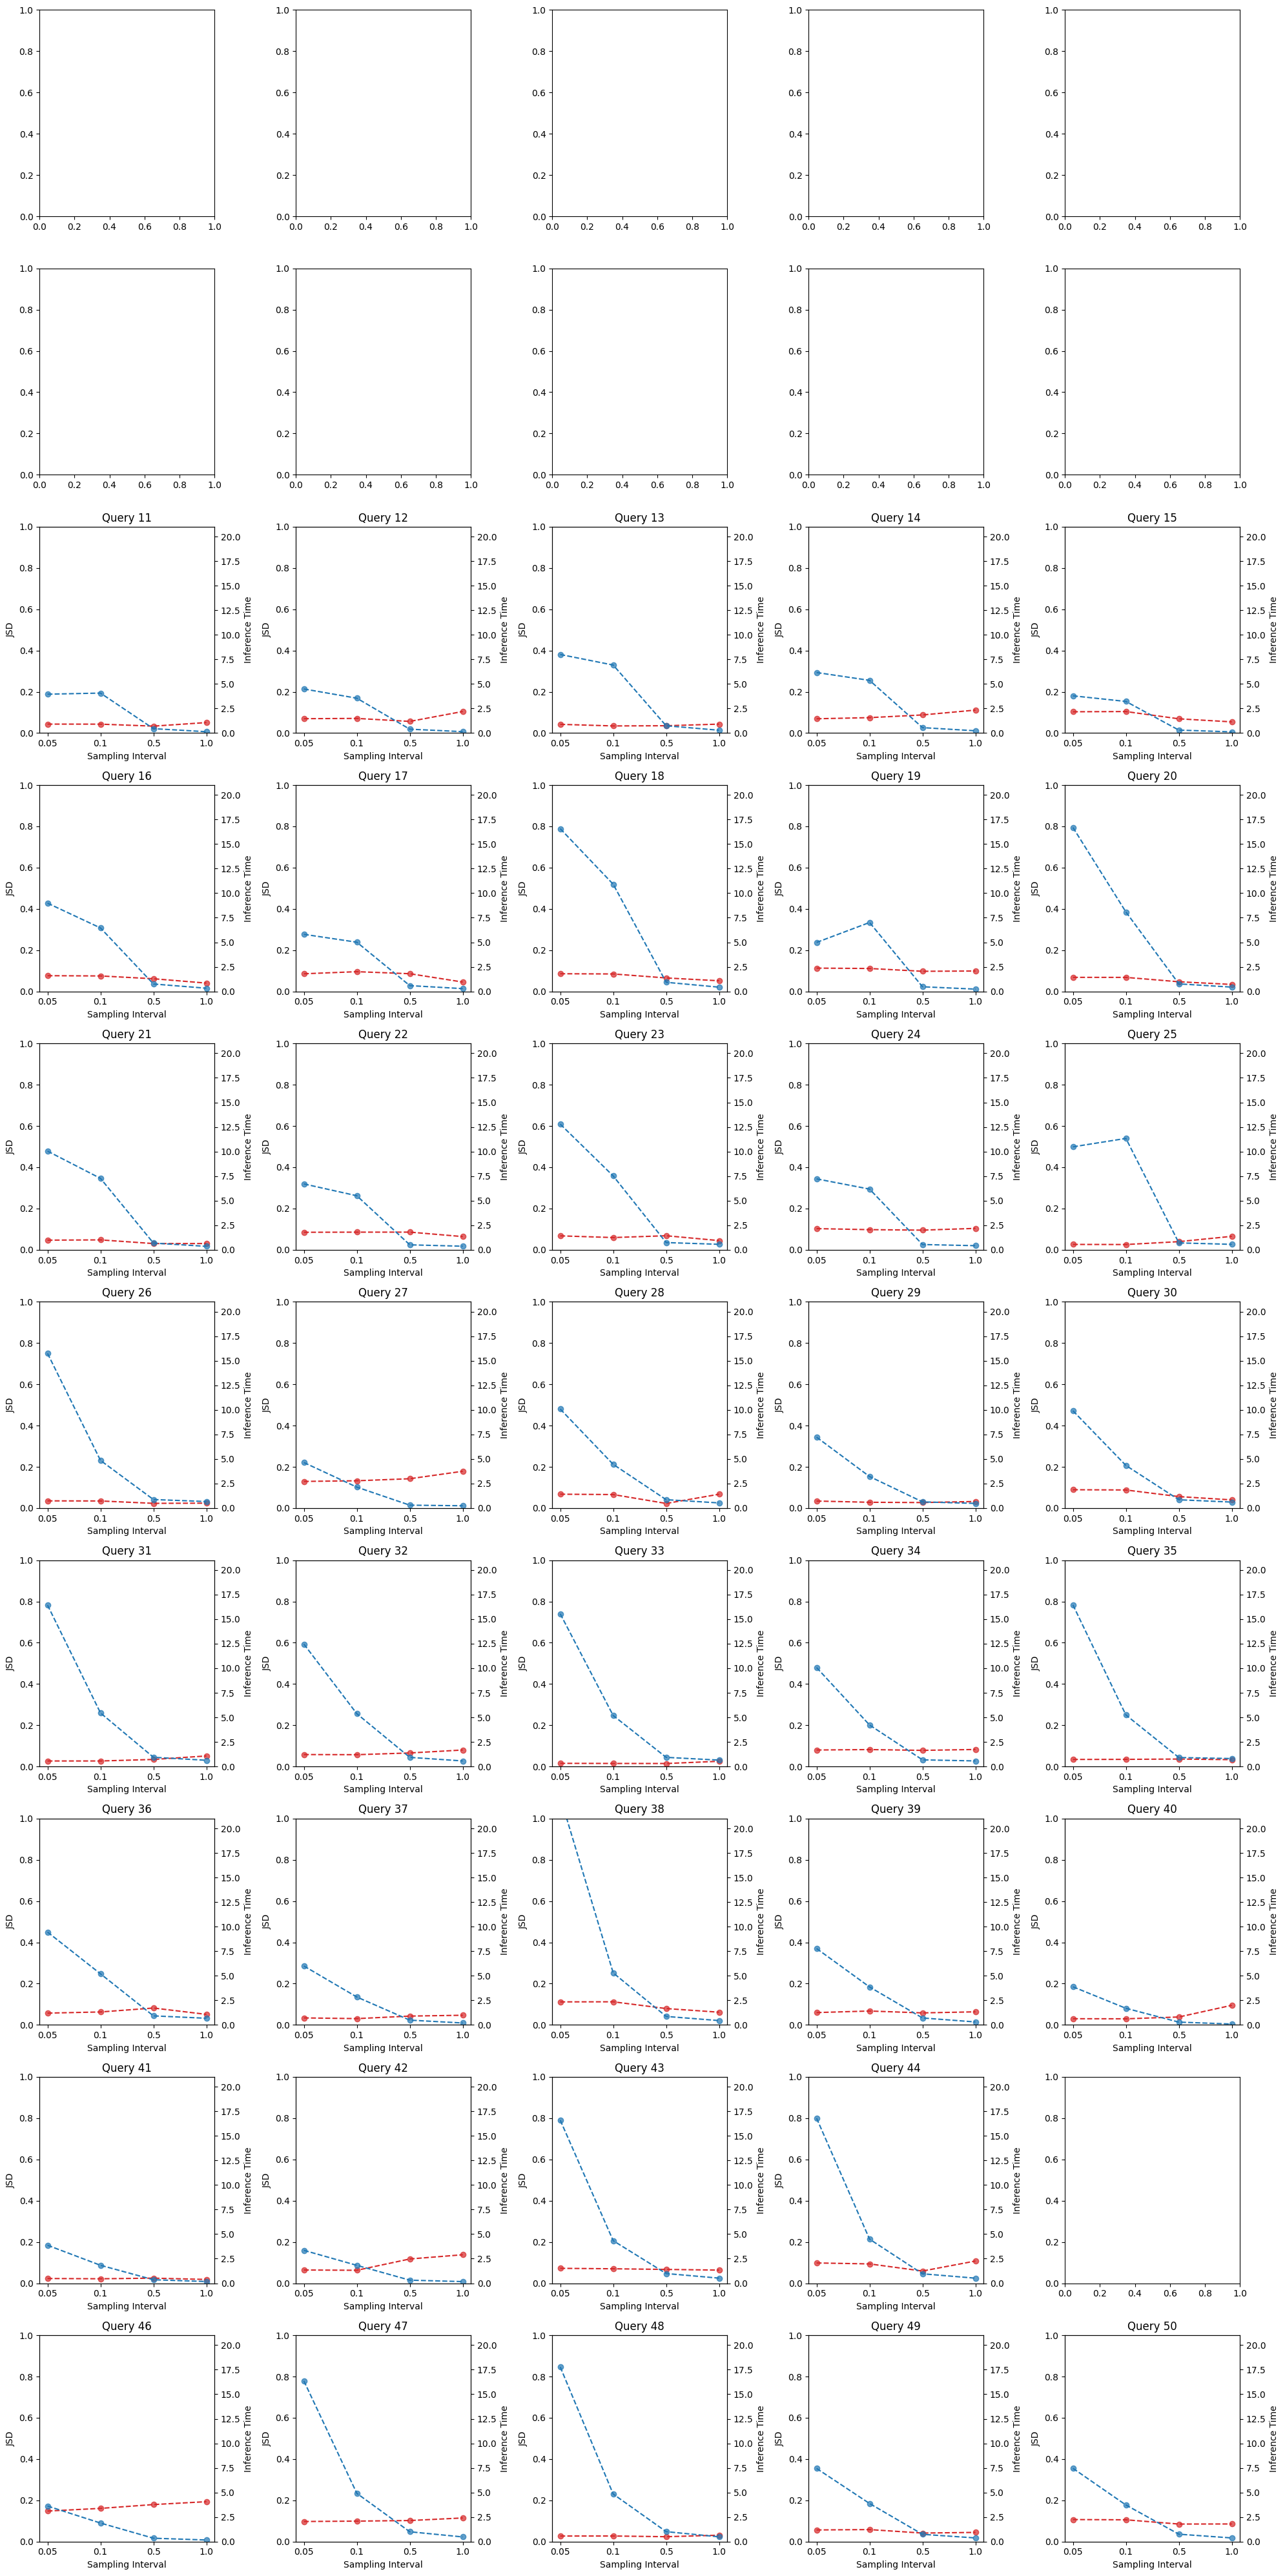

In [51]:
sampling_interval_query_single(df)

In [21]:
# Define a function that creates these types of plots for a specific intervention_type. 
def sampling_interval_expt(data, intv_type=None, avg=False): 
    if intv_type == None: 
        data = data
    else:
        # Filter the dataframe for the specific intervention_type
        data = data[data['intv_type'] == intv_type]
    # Get the total inference time, jsd and number of slices for the 3 sampling intervals
    inf_time_7 = sum(data['inference_time_7'].dropna())
    inf_time_6 = sum(data['inference_time_6'].dropna())
    inf_time_5 = sum(data['inference_time_5'].dropna())
    
    avg_inf_time_7 = inf_time_7 / len(data['inference_time_7'].dropna())
    avg_inf_time_6 = inf_time_6 / len(data['inference_time_6'].dropna())
    avg_inf_time_5 = inf_time_5 / len(data['inference_time_5'].dropna())
    
    jsd_7 = sum(data['jsd_7'].dropna())
    jsd_6 = sum(data['jsd_6'].dropna())
    jsd_5 = sum(data['jsd_5'].dropna())
    
    avg_jsd_7 = jsd_7 / len(data['jsd_7'].dropna())
    avg_jsd_6 = jsd_6 / len(data['jsd_6'].dropna())
    avg_jsd_5 = jsd_5 / len(data['jsd_5'].dropna())
    
    num_slices_7 = sum(data['num_slices_7'].dropna())
    num_slices_6 = sum(data['num_slices_6'].dropna())
    num_slices_5 = sum(data['num_slices_5'].dropna())
    
    if avg: 
        # Create the plot
        fig, ax1 = plt.subplots()
        
        color = 'tab:red'
        ax1.set_xlabel('Sampling Interval')
        ax1.set_ylabel('Average JSD', color=color)        
        ax1.scatter([0.1, 0.5, 1.0], [avg_jsd_5, avg_jsd_6, avg_jsd_7], color=color, alpha=0.7)
        ax1.plot([0.1, 0.5, 1.0], [avg_jsd_5, avg_jsd_6, avg_jsd_7], color=color, linestyle='dashed')
        ax1.tick_params(axis='y', labelcolor=color)
        
        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Average Inference Time', color=color)
        ax2.scatter([0.1, 0.5, 1.0], [avg_inf_time_5, avg_inf_time_6, avg_inf_time_7], color=color, alpha=0.7)
        ax2.plot([0.1, 0.5, 1.0], [avg_inf_time_5, avg_inf_time_6, avg_inf_time_7], color=color, linestyle='dashed')
        ax2.tick_params(axis='y', labelcolor=color)
        
        fig.tight_layout()
        plt.show()
        
    else:
        # Create the plot
        fig, ax1 = plt.subplots()
        
        color = 'tab:red'
        ax1.set_xlabel('Sampling Interval')
        ax1.set_ylabel('Total JSD', color=color)
        # Scatter plot of the sampling interval and jsd
        ax1.scatter([0.1, 0.5, 1.0], [jsd_5, jsd_6, jsd_7], color=color, alpha=0.7)
        ax1.plot([0.1, 0.5, 1.0], [jsd_5, jsd_6, jsd_7], color=color, linestyle='dashed')
        ax1.tick_params(axis='y', labelcolor=color)
        
        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Inference Time', color=color)
        ax2.scatter([0.1, 0.5, 1.0], [inf_time_5, inf_time_6, inf_time_7], color=color, alpha=0.7)
        ax2.plot([0.1, 0.5, 1.0], [inf_time_5, inf_time_6, inf_time_7], color=color, linestyle='dashed')
        ax2.tick_params(axis='y', labelcolor=color)
        
        fig.tight_layout()
        plt.show()
        
    # Create the plot for the number of slices
    fig2, ax1 = plt.subplots()
    
    color = 'tab:red'
    ax1.set_xlabel('Sampling Interval')
    if avg: 
        ax1.set_ylabel('Average JSD', color=color)
        ax1.scatter([0.1, 0.5, 1.0], [avg_jsd_5, avg_jsd_6, avg_jsd_7], color=color, alpha=0.7)
        ax1.plot([0.1, 0.5, 1.0], [avg_jsd_5, avg_jsd_6, avg_jsd_7], color=color, linestyle='dashed')
        ax1.tick_params(axis='y', labelcolor=color)
    else:
        ax1.set_ylabel('Total JSD', color=color)
        # Scatter plot of the sampling interval and jsd
        ax1.scatter([0.1, 0.5, 1.0], [jsd_5, jsd_6, jsd_7], color=color, alpha=0.7)
        ax1.plot([0.1, 0.5, 1.0], [jsd_5, jsd_6, jsd_7], color=color, linestyle='dashed')
        ax1.tick_params(axis='y', labelcolor=color)
    
    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Number of Slices', color=color)
    ax2.scatter([0.1, 0.5, 1.0], [num_slices_5, num_slices_6, num_slices_7], color=color, alpha=0.7)
    ax2.plot([0.1, 0.5, 1.0], [num_slices_5, num_slices_6, num_slices_7], color=color, linestyle='dashed')
    ax2.tick_params(axis='y', labelcolor=color)
    
    fig2.tight_layout()
    plt.show()
    

In [ ]:
sampling_interval_expt(df, intv_type=None)

In [ ]:
sampling_interval_expt(df, intv_type=None, avg=True)

In [ ]:
sampling_interval_expt(df, 'conditional', avg=True)

In [ ]:
sampling_interval_expt(df, 'parameter_intervention', avg=True)

In [ ]:
sampling_interval_expt(df, 'additive', avg=True)

In [ ]:
sampling_interval_expt(df, 'subtractive', avg=True)